# quixviz demo

Zoom-aware timeseries against a live Quix data lake.

- **Preflight** asks the catalog for MIN/MAX/COUNT (uses Iceberg manifest stats).
- **Bucket size** snaps to a "nice" 1·10^k / 2·10^k / 5·10^k value based on visible pixels.
- **Three ways to drive zoom**: built-in Plotly rangeslider (no refetch), `FigureWidget` relayout events (ipywidgets), or an explicit `range_slider` (ipywidgets).

In [ ]:
import os
import quixviz as qv
from quixviz.notebook import attach_jupyter, range_slider

URL = os.environ["QUIX_LAKE_URL"]
TOKEN = os.environ["QUIX_LAKE_TOKEN"]

client = qv.connect(URL, token=TOKEN)

## Build a chart

`ac_telemetry` stores F1-style telemetry. `timestamp_ms` is numeric epoch ms, so we pass `x_unit="ms"`. Requesting `min`/`max`/`avg` gives us a shaded envelope around the mean line — so spikes survive coarse zoom.

In [2]:
chart = qv.timeseries(
    client,
    table="ac_telemetry",
    x="timestamp_ms",
    y=["speedKmh"],
    agg=["min", "max", "avg"],
    x_unit="ms",
)

x_min, x_max, count = chart.preflight()
span_days = (x_max - x_min) / 86_400_000
print(f"range spans {span_days:.2f} days over {count:,} rows")

range spans 21.68 days over 705,807 rows


## Option 1 — Plotly rangeslider + buttons (no extra deps, no refetch)

`chart.show()` now includes a rangeslider underneath and `1m / 10m / 1h / 1d / 1w / all` quick-jump buttons at the top. Pure HTML/JS — works in Colab. The slider only zooms in-browser (Plotly can't call back into Python without a widget runtime), so the bucket size is fixed at whatever was most recently fetched. Good for quick browsing, not for diving deep.

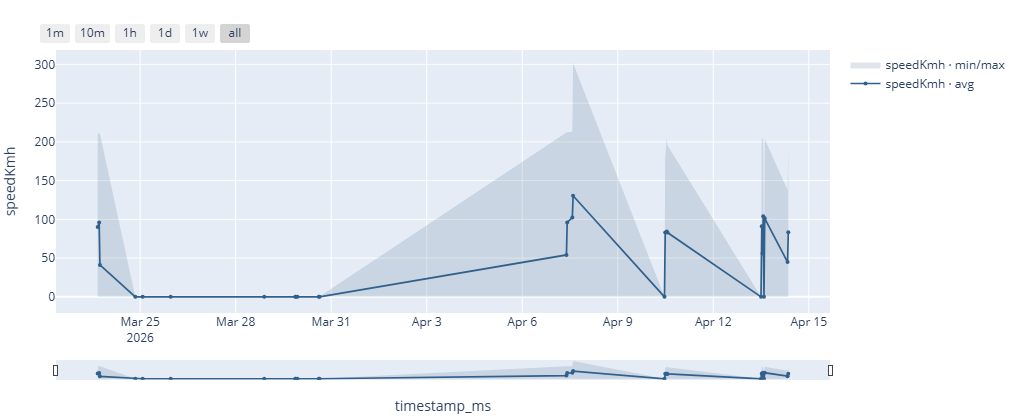

In [3]:
chart.show()

## Option 2 — ipywidgets range slider (refetches at new bucket)

`range_slider(chart)` renders a `FloatRangeSlider` above the chart. Each drag calls `chart.zoom_to(...)`, which recomputes the bucket and refetches. The readout under the slider shows the current window and bucket size.

Requires `ipywidgets`. Works in JupyterLab, classic Jupyter, VS Code notebooks, and Colab (Colab supports ipywidgets).

In [4]:
range_slider(chart)

## Option 3 — FigureWidget relayout (zoom the chart itself)

`attach_jupyter` returns a `FigureWidget` that listens for pan/zoom directly on the chart. Box-zoom or use the rangeslider — either fires `xaxis.range` events back into Python and refetches.

Also requires `ipywidgets`.

In [5]:
widget = attach_jupyter(chart)
widget

FigureWidget({
    'data': [{'fill': 'toself',
              'fillcolor': 'rgba(77,109,140,0.18)',
              'hoverinfo': 'skip',
              'legendgroup': 'speedKmh',
              'line': {'width': 0},
              'name': 'speedKmh · min/max',
              'showlegend': True,
              'type': 'scatter',
              'uid': '6d6ed61f-9bbc-4859-93ed-19e8131f0a0b',
              'x': array(['2026-03-23 16:00:00+00:00', '2026-03-23 17:06:40+00:00',
                          '2026-03-23 17:40:00+00:00', '2026-03-24 20:20:00+00:00',
                          '2026-03-25 01:53:20+00:00', '2026-03-25 23:00:00+00:00',
                          '2026-03-28 21:33:20+00:00', '2026-03-29 20:53:20+00:00',
                          '2026-03-29 21:26:40+00:00', '2026-03-29 22:33:20+00:00',
                          '2026-03-30 14:40:00+00:00', '2026-03-30 15:13:20+00:00',
                          '2026-04-07 09:20:00+00:00', '2026-04-07 09:53:20+00:00',
                          '20

## Programmatic API

If you'd rather drive from cells: `zoom_to(start, end)`, `zoom_last("1h")`, `reset()`. Each returns a fresh figure at the new LOD.

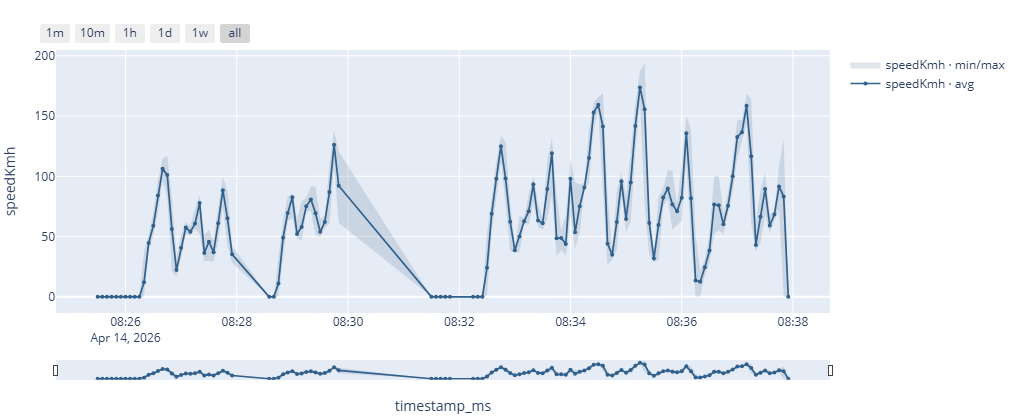

In [6]:
chart.zoom_last("1h")

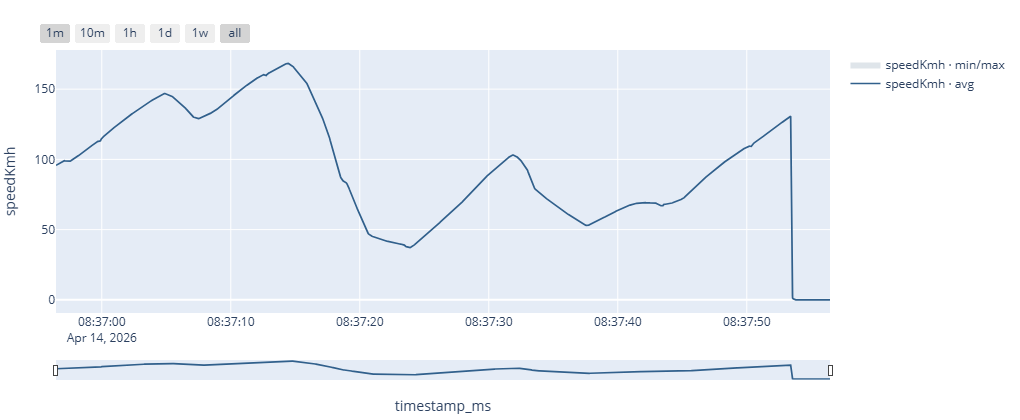

In [7]:
chart.zoom_last("1m")

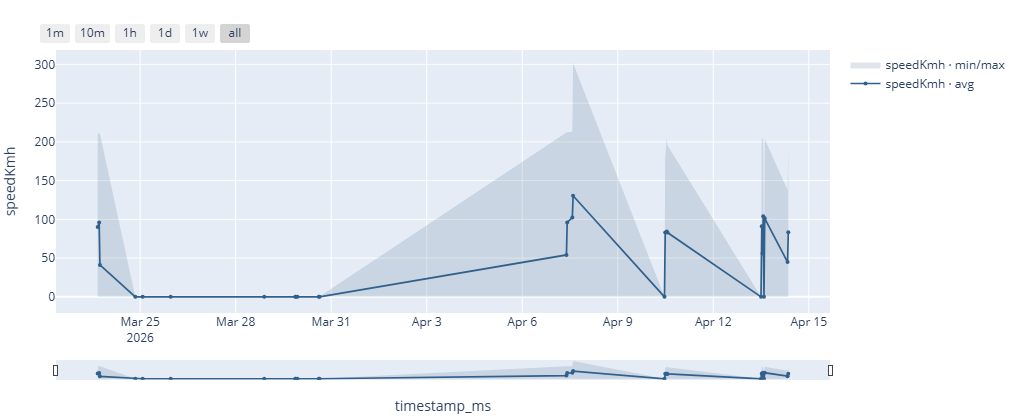

In [8]:
chart.reset()

## Verify LOD math across four window sizes

In [9]:
for label, span_ms in [("full range", x_max - x_min), ("1 hour", 3_600_000), ("1 minute", 60_000), ("1 second", 1_000)]:
    chart.fetch(x_min=x_max - span_ms, x_max=x_max)
    print(f"{label:>12} -> bucket_ms={chart._last_bucket_ms:>10,}   rows={len(chart._df):>5}")

  full range -> bucket_ms= 2,000,000   rows=   28
      1 hour -> bucket_ms=     5,000   rows=  120
    1 minute -> bucket_ms=        50   rows= 1201
    1 second -> bucket_ms=         1   rows=   51
